In [1]:
import os
import math
import random
import json
import glob

import matplotlib.pyplot as plt

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [2]:
import shutil

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
# структура скачанного датасета 
def print_dir_tree(root_dir, max_files = 2, prefix = ""):
   
    items = sorted(os.listdir(root_dir))
    dirs = [d for d in items if os.path.isdir(os.path.join(root_dir, d))]
    files = [f for f in items if os.path.isfile(os.path.join(root_dir, f))]

    for i, d in enumerate(dirs):
        connector = "└─ " if i == len(dirs) - 1 and not files else "├─ "
        print(prefix + connector + d)
        extension = "    " if i == len(dirs) - 1 and not files else "│   "
        print_dir_tree(os.path.join(root_dir, d), max_files, prefix + extension)

    for i, f in enumerate(files[:max_files]):
        connector = "└─ " if i == len(files[:max_files]) - 1 else "├─ "
        print(prefix + connector + f)
    if len(files) > max_files:
        print(prefix + f"└─ ... ({len(files)-max_files} more files)")

dataset_root = "autoriaNumberplateOcrRu"
print_dir_tree(dataset_root)

├─ test
│   ├─ ann
│   │   ├─ A001BP54.json
│   │   └─ A001PC71.json
│   │   └─ ... (2843 more files)
│   └─ img
│       ├─ A001BP54.png
│       └─ A001PC71.png
│       └─ ... (2843 more files)
├─ train
│   ├─ ann
│   │   ├─ 11_11_2014_10_42_11_230_0.json
│   │   └─ 11_11_2014_10_42_1_183_0.json
│   │   └─ ... (49380 more files)
│   └─ img
│       ├─ 11_11_2014_10_42_11_230_0.png
│       └─ 11_11_2014_10_42_1_183_0.png
│       └─ ... (49380 more files)
├─ val
│   ├─ ann
│   │   ├─ A001BO92.json
│   │   └─ A001CX61.json
│   │   └─ ... (4891 more files)
│   └─ img
│       ├─ A001BO92.png
│       └─ A001CX61.png
│       └─ ... (4891 more files)
└─ license.txt


In [19]:
DATASET_ROOT = "autoriaNumberplateOcrRu"

BATCH_SIZE = 32
IMG_HEIGHT = 32
IMG_WIDTH = 128
MAX_EPOCHS = 250
NUM_WORKERS = 0
RANDOM_SEED = 42

MAX_TRAIN_SAMPLES = 3000
MAX_TEST_SAMPLES = 300


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [20]:
ALPHABET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
blank_idx = 0
char2idx = {c: i + 1 for i, c in enumerate(ALPHABET)}
idx2char = {i + 1: c for i, c in enumerate(ALPHABET)}
vocab_size = len(ALPHABET) + 1

train_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

test_transforms = train_transforms

class NumberplateOCRDataset(Dataset):
    def __init__(self, root, split, transforms=None, max_samples=None):
        self.root = root
        self.split = split
        self.transforms = transforms
        ann_dir = os.path.join(root, split, "ann")
        self.ann_paths = glob.glob(os.path.join(ann_dir, "*.json"))
        self.ann_paths.sort()
        if max_samples is not None:
            self.ann_paths = self.ann_paths[:max_samples]

    def __len__(self):
        return len(self.ann_paths)

    def encode_text(self, text):
        return [char2idx[c] for c in str(text) if c in char2idx]

    def __getitem__(self, idx):
        ann_path = self.ann_paths[idx]
        with open(ann_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        name = data["name"]
        text = str(data.get("description", ""))
        img_rel = os.path.join(self.split, "img", name + ".png")
        img_path = os.path.join(self.root, img_rel)
        image = Image.open(img_path).convert("RGB")
        if self.transforms is not None:
            image = self.transforms(image)
        label = torch.tensor(self.encode_text(text), dtype=torch.long)
        return image, label, text

train_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "train", transforms=train_transforms, max_samples=MAX_TRAIN_SAMPLES
)
test_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "test", transforms=test_transforms, max_samples=MAX_TEST_SAMPLES
)

def collate_fn(batch):
    batch = [b for b in batch if len(b[1]) > 0]
    images = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    texts = [b[2] for b in batch]
    images = torch.stack(images, dim=0)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    targets = torch.cat(labels, dim=0)
    return images, targets, label_lengths, texts

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

tensor([11,  1,  9,  9, 21, 21,  7,  1])


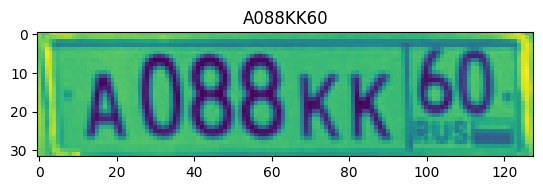

In [21]:
image, label, text = train_dataset[0]

print(label)
plt.title(text)
plt.imshow(image[0, :, :])
plt.show()

In [22]:
class CNNBackbone(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 2), (2, 1), (0, 1)),

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 2), (2, 1), (0, 1))
        )

    def forward(self, x):
        return self.net(x)


class CRNN(nn.Module):
    def __init__(self, img_h, num_channels, num_classes, hidden_size=256, num_layers=2):
        super().__init__()
        self.backbone = CNNBackbone(num_channels)
        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.LSTM(
            input_size=256,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=False
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        x = self.pool(feat)
        b, c, h, w = x.size()
        x = x.view(b, c, w)
        x = x.permute(2, 0, 1)
        x, _ = self.rnn(x)
        x = self.fc(x)
        x = x.log_softmax(2)
        return x

model = CRNN(IMG_HEIGHT, 1, vocab_size).to(device)
criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [23]:
def decode_sequence(seq):
    seq = seq.cpu().numpy().tolist()
    prev = None
    out = []
    for s in seq:
        if s != blank_idx and s != prev:
            if s in idx2char:
                out.append(idx2char[s])
        prev = s
    return "".join(out)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, targets, target_lengths, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)
        logits = model(images)
        T_cur, N_cur, C_cur = logits.size()
        input_lengths = torch.full(
            size=(N_cur,), fill_value=T_cur, dtype=torch.long, device=logits.device
        )
        loss = criterion(logits, targets, input_lengths, target_lengths)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item()
    return running_loss / max(1, len(loader))

def evaluate(model, loader, max_batches=3):
    model.eval()
    samples = []
    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            pred = logits.permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = texts[i]
                samples.append((gt, decoded))
            if bi + 1 >= max_batches:
                break
    return samples

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch}/{MAX_EPOCHS}, train loss: {train_loss:.4f}")

test_samples = evaluate(model, test_loader, max_batches=2)
for i, (gt, pred) in enumerate(test_samples[:20]):
    print(f"{i+1}. GT: {gt} | PRED: {pred}")

Epoch 1/250, train loss: 3.0052
Epoch 2/250, train loss: 2.2296
Epoch 3/250, train loss: 2.0676
Epoch 4/250, train loss: 1.9137
Epoch 5/250, train loss: 1.7240
Epoch 6/250, train loss: 1.5057
Epoch 7/250, train loss: 1.1433
Epoch 8/250, train loss: 0.6699
Epoch 9/250, train loss: 0.3108
Epoch 10/250, train loss: 0.1392
Epoch 11/250, train loss: 0.0897
Epoch 12/250, train loss: 0.0559
Epoch 13/250, train loss: 0.0355
Epoch 14/250, train loss: 0.0322
Epoch 15/250, train loss: 0.0273
Epoch 16/250, train loss: 0.0194
Epoch 17/250, train loss: 0.0214
Epoch 18/250, train loss: 0.0156
Epoch 19/250, train loss: 0.0063
Epoch 20/250, train loss: 0.0113
Epoch 21/250, train loss: 0.0066
Epoch 22/250, train loss: 0.0098
Epoch 23/250, train loss: 0.0190
Epoch 24/250, train loss: 0.0187
Epoch 25/250, train loss: 0.0080
Epoch 26/250, train loss: 0.0041
Epoch 27/250, train loss: 0.0039
Epoch 28/250, train loss: 0.0023
Epoch 29/250, train loss: 0.0011
Epoch 30/250, train loss: 0.0029
Epoch 31/250, train

In [24]:
def evaluate_with_metrics(model, loader, max_batches=10, max_print=20):
    model.eval()
    total_seq = 0
    correct_seq = 0
    total_chars = 0
    correct_chars = 0
    samples = []
    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            pred = logits.permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = str(texts[i])
                samples.append((gt, decoded))
                total_seq += 1
                if decoded == gt:
                    correct_seq += 1
                L = max(len(gt), len(decoded))
                if L > 0:
                    total_chars += L
                    correct_chars += sum(
                        1 for a, b in zip(gt.ljust(L), decoded.ljust(L)) if a == b
                    )
            if bi + 1 >= max_batches:
                break
    seq_acc = correct_seq / max(1, total_seq)
    char_acc = correct_chars / max(1, total_chars)
    print(f"Exact plate accuracy: {seq_acc * 100:.2f}%")
    print(f"Character accuracy:   {char_acc * 100:.2f}%")
    print()
    for i, (gt, pred) in enumerate(samples[:max_print]):
        print(f"{i+1}. GT: {gt} | PRED: {pred}")
    return seq_acc, char_acc, samples

seq_acc, char_acc, test_samples = evaluate_with_metrics(model, test_loader, max_batches=10, max_print=30)

Exact plate accuracy: 31.33%
Character accuracy:   84.94%

1. GT: A001BP54 | PRED: A001BP54
2. GT: A001PC71 | PRED: A001PC21
3. GT: A002KX152 | PRED: A002KX152
4. GT: A002XC763 | PRED: A002KC23
5. GT: A002XY89 | PRED: A002XY199
6. GT: A003CX196 | PRED: A003CX35
7. GT: A004OE23 | PRED: A004OE29
8. GT: A005AX26 | PRED: A005AX36
9. GT: A006AA10 | PRED: A006AA10
10. GT: A007AE799 | PRED: A007AE199
11. GT: A007CH35 | PRED: A007CH35
12. GT: A007CT163 | PRED: A007CT33
13. GT: A009XX123 | PRED: A009XX121
14. GT: A010TB34 | PRED: A010TB35
15. GT: A011AB39 | PRED: A011AB199
16. GT: A011YB42 | PRED: A011KB22
17. GT: A012AA05 | PRED: A012AA35
18. GT: A012AH716 | PRED: A012AH176
19. GT: A015YO82 | PRED: A015XO62
20. GT: A019AX122 | PRED: A019AX177
21. GT: A020AA06 | PRED: A020AA96
22. GT: A020AO198 | PRED: A020AO198
23. GT: A020KE123 | PRED: A020KE23
24. GT: A020YK134 | PRED: A020YK196
25. GT: A021HP82 | PRED: A021HP52
26. GT: A021XH86 | PRED: A021XH36
27. GT: A025EE73 | PRED: A025EE73
28. GT: A026